<a href="https://colab.research.google.com/github/lindseycarlson23/foodhub/blob/main/Learner_Notebook_Full_Code_LC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# mount to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read the data
df = pd.read_csv('/content/drive/MyDrive/AIML_Program/Python_Foundations/foodhub_order.csv')

In [ ]:
# view first 5 rows to ensure data loaded correctly
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
# view last 5 rows of dataset
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
df.shape

(1898, 9)

#### Observations:


*   The dataset has 1898 rows and 9 columns.



### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [ ]:
# looking at why the rating column is an object datatype
df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

#### Observations:

*   There are 4 object datatype columns and 5 numerical datatype columns.
*   All of the columns have 1898 entries, but the ratings column includes the entry "Not given." This causes Python to interpret the column as an object datatype. It should be a numerical datatype.
*    All the "Not given" values should be read as missing values (NaN), so we need to replace them.

In [ ]:
# replacing values with nan
df['rating'] = df['rating'].replace('Not given', np.nan)

# changing the datatype to float to match the other datatypes in the dataset
df['rating'] = df['rating'].astype(float)

# confirming ratings values have been changed from "Not given" to NaN
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24


In [ ]:
# check the datatype for the rating columns again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


The rating dataype is now float.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# check for missing values
df.isnull().sum()

order_id                   0
customer_id                0
restaurant_name            0
cuisine_type               0
cost_of_the_order          0
day_of_the_week            0
rating                   736
food_preparation_time      0
delivery_time              0
dtype: int64

#### Observations:

*   There are technically missing values since we changed the "Not given" ratings to Nan.
*   These will be left alone so that later we can filter out the orders with null values but not permanantly remove them.



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# include all datatypes so that we can see the top categorical values
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1162.0,NaN,NaN,NaN,4.344234,0.741478,3.0,4.0,5.0,5.0,5.0
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations:

*   Once an order is placed, it takes a minimum of 20 min, a maximum of 35 min, and an average of about 27 min for the food to be prepared.
*   The top restaurant is Shake Shack, with over 11% of the orders.
*   Weekend orders account for over 71% of the orders.
*   Ratings only range between 3 and 5.



### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# check for missing values
df.isnull().sum()

order_id                   0
customer_id                0
restaurant_name            0
cuisine_type               0
cost_of_the_order          0
day_of_the_week            0
rating                   736
food_preparation_time      0
delivery_time              0
dtype: int64

#### Observations:

*   There are 736 orders without a rating, accounting for almost 39% of the orders.



### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

### **Observations on order_id**

In [ ]:
# checking that order numbers are unique
df['order_id'].nunique()

1898

The number of order_ids matches the number of rows, indicating that there are not any duplication errors.

### **Observations on customer_id**




In [ ]:
# checking if customer numbers are unique
df['customer_id'].nunique()

1200

There are only 1200 unique customer_ids but 1898 orders indicating that there are repeat customers.

In [ ]:
# checking the order count for each customer ID
orders_per_customer = df['customer_id'].value_counts()

# checking for repeat customers
repeat_customers = orders_per_customer[orders_per_customer > 1].count()
print(repeat_customers)

416


There are 416 repeat customers.

### **Observations on restaurant_name**

There are 178 different restaurants with orders.

In [ ]:
# look at how many different restaurants have orders and what is the top restaurant
df['restaurant_name'].describe()

count            1898
unique            178
top       Shake Shack
freq              219
Name: restaurant_name, dtype: object

In [ ]:
# standardize restaurant names  # this was added from watching the project debrief
df['restaurant_name'] = df['restaurant_name'].str.lower()
df['restaurant_name'] = df['restaurant_name'].str.strip()

In [ ]:
# list the top 10 restaurants with the number of orders associated with each
order_counts = df['restaurant_name'].value_counts()
top_10_restaurants = order_counts.head(10)
print(top_10_restaurants)

restaurant_name
shake shack                      219
the meatball shop                132
blue ribbon sushi                119
blue ribbon fried chicken         96
parm                              68
redfarm broadway                  59
redfarm hudson                    55
tao                               49
han dynasty                       46
blue ribbon sushi bar & grill     44
Name: count, dtype: int64


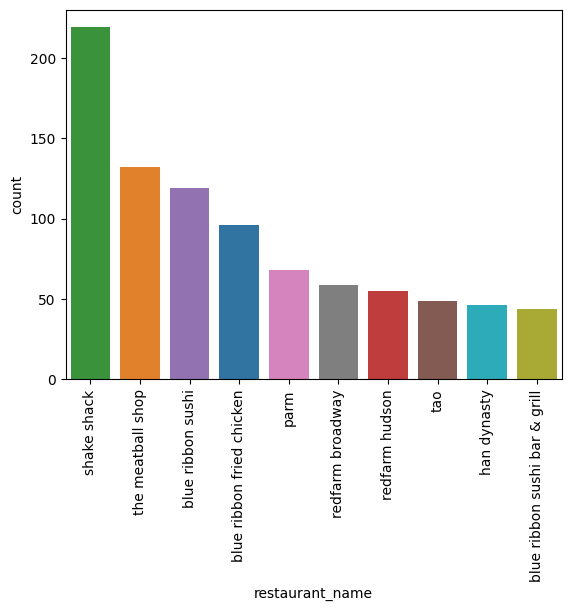

In [ ]:
df_top_10_restaurants = df[df['restaurant_name'].isin(top_10_restaurants.index)]

sns.countplot(data=df_top_10_restaurants, x='restaurant_name', order=top_10_restaurants.index, hue='restaurant_name')
plt.xticks(rotation=90)
plt.show()

### **Observations on the cuisine_type**

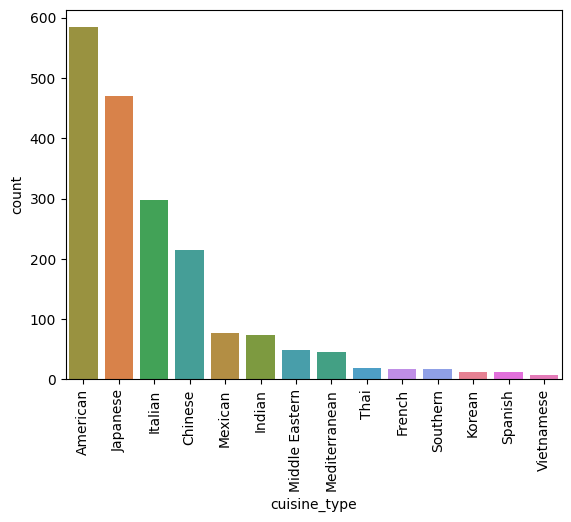

In [ ]:
# bar graph with the cuisines ordered by order frequency
sns.countplot(data=df, x='cuisine_type', hue='cuisine_type', order=df['cuisine_type'].value_counts().index);
plt.xticks(rotation=90);

The top 5 cuisine types are American, Japanese, Italian, Chinese, and Mexican.

### **Observations on cost_of_the_order**

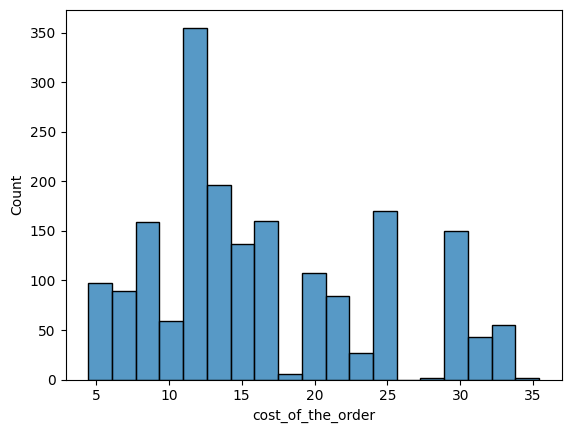

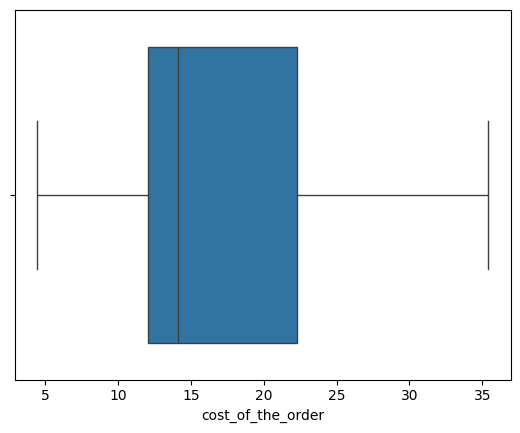

In [ ]:
sns.histplot(data=df, x='cost_of_the_order')
plt.show()
sns.boxplot(data=df, x='cost_of_the_order')
plt.show()

*   The distribution is slightly right skewed.
*   There are no outliers.




### **Observations on food_preparation_time**

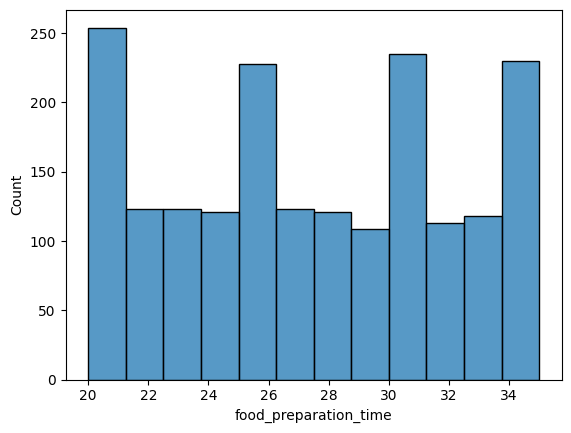

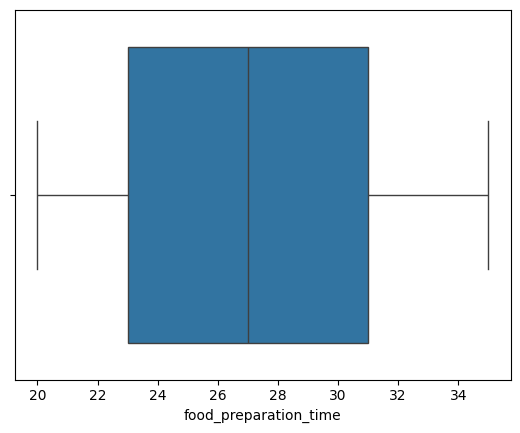

In [ ]:
sns.histplot(data=df, x='food_preparation_time')
plt.show()
sns.boxplot(data=df, x='food_preparation_time')
plt.show()

In [ ]:
df['food_preparation_time'].describe()

count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64

*   The times are randomly distributed.
*   The average time is about 27 minutes.



### **Observations on day_of_the_week**

<Axes: xlabel='day_of_the_week', ylabel='count'>

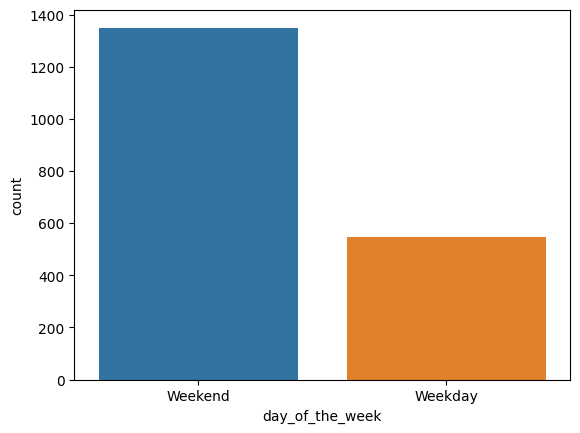

In [ ]:
# countplot to show distribution between weekdays and weekends
sns.countplot(data=df,x='day_of_the_week',hue='day_of_the_week')

*   There are over twice as many orders on Weekends compared to Weekdays.

### **Observations on rating**

In [ ]:
df['rating'].describe()

count    1162.000000
mean        4.344234
std         0.741478
min         3.000000
25%         4.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: rating, dtype: float64

In [ ]:
df['rating'].value_counts()

rating
5.0    588
4.0    386
3.0    188
Name: count, dtype: int64

In [ ]:
df['rating'].isnull().sum()

736

<Axes: xlabel='rating', ylabel='count'>

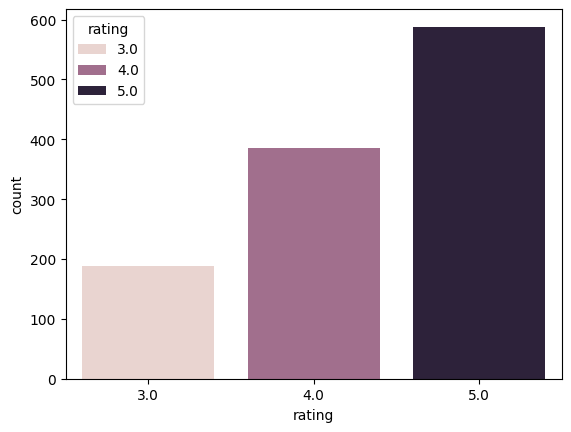

In [ ]:
sns.countplot(data=df,x='rating',hue='rating')

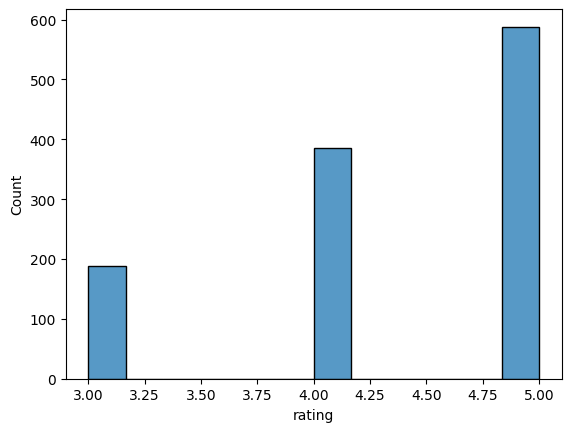

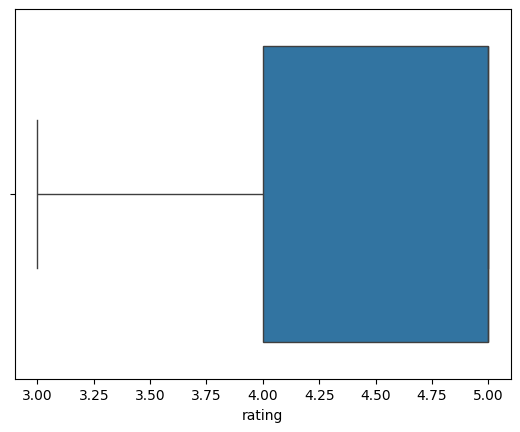

In [ ]:
sns.histplot(data=df,x='rating')
plt.show()
sns.boxplot(data=df,x='rating')
plt.show()

*   There are twice as many 4.0 ratings as 3.0, and three times as many 5.0 ratings.
*   There are no 1 or 2 ratings.
*   75% of the ratings are 4 or 5.
*   There are 736 orders without a rating.

### **Observations on delivery_time**

In [ ]:
df['delivery_time'].describe()

count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64

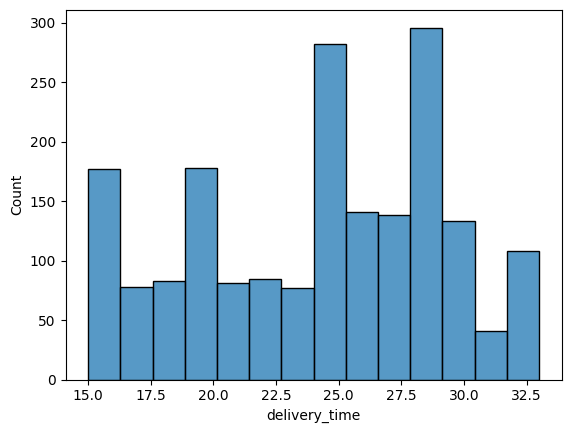

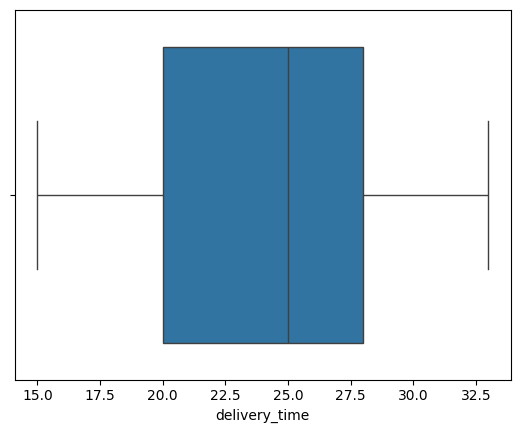

In [ ]:
sns.histplot(data=df, x='delivery_time')
plt.show()
sns.boxplot(data=df, x='delivery_time')
plt.show()

*   The delivery times are randomly distributed as there are multiple modes, though it could be considered slightly left skewed.
*   The mean is about 24 min, and the median is 24 min.



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# count orders per restaurant
order_counts = df['restaurant_name'].value_counts()

# get the top 5 restaurants
top_restaurants = order_counts.head(5)
print(top_restaurants)

# sum of orders from top five restaurants
print("Sum of order from top 5 restaurants: ", top_restaurants.sum())

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64
Sum of order from top 5 restaurants:  634


#### Observations:

*   The top 5 restaurants are Shake Shack with 219 orders, The Meatball Shop with 132 orders, Blue Ribbon Sushi with 119 orders, Blue Ribbon Fried Chicken with 96 orders, and Parm with 68 orders.
*   This accounts for 634/1898 orders, or about 1/3 of the orders.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

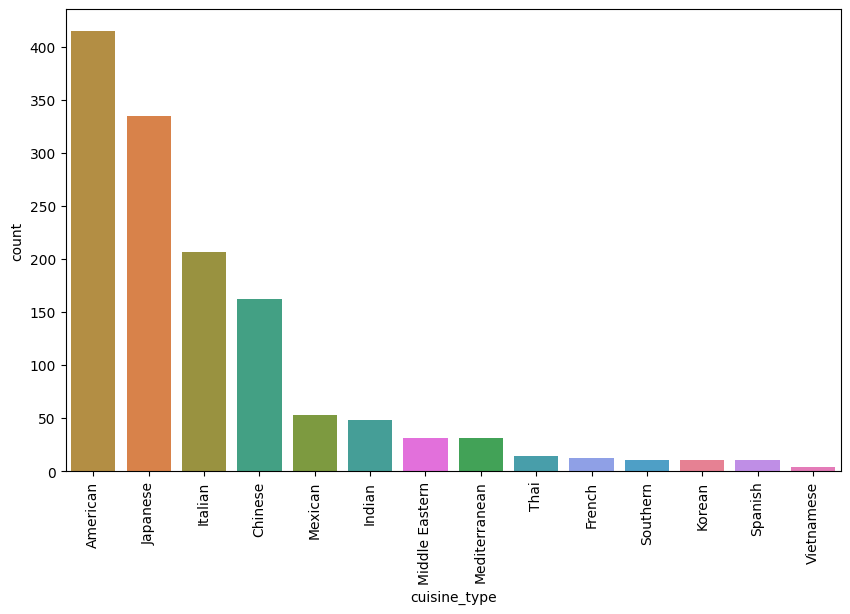

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df[df['day_of_the_week'] == 'Weekend'], x='cuisine_type', order=df['cuisine_type'].value_counts().index, hue='cuisine_type')
plt.xticks(rotation=90)
plt.show()

#### Observations:


*   The most popular cuisine on weekends is American.



### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# find the number of orders that cost more than 20
more_than_20 = df[df['cost_of_the_order'] > 20]
more_than_20.shape

(555, 9)

#### Observations:


*   There are 555 orders that cost more than $20, accounting for about 29% of the orders.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
df['delivery_time'].describe()

count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64

#### Observations:
*   The mean order delivery time is about 24 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# checking the order count for each customer ID
orders_per_customer = df['customer_id'].value_counts()

# listing the top three with the number of orders
orders_per_customer.head(3)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

#### Observations:
*   The top three customers are 52832 with 13 orders, 47440 with 10 orders, and 83287 with 9 orders.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


Heatplot of all numerical values

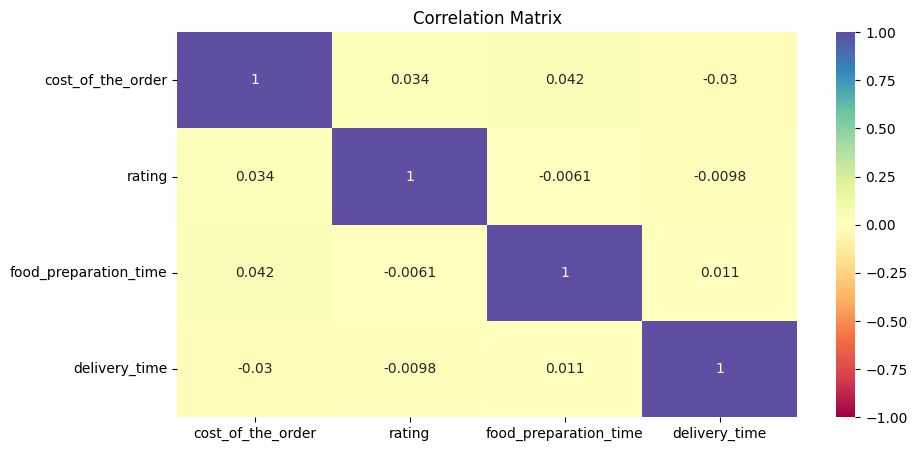

In [ ]:
# calculate correlation matrix for numerical variables

columns_for_corr = ["cost_of_the_order", "rating", "food_preparation_time", "delivery_time"]
plt.figure(figsize=(10,5))
sns.heatmap(df[columns_for_corr].corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.title('Correlation Matrix')
plt.show()

*   There is little correlation between the numerical values in this dataset.
*   There is a very slight positive correlation between cost_of_the_order and food_preparation_time, which makes sense since larger orders would take long to prepare.
*   There is also a slight negative correlation between the delivery_time and the cost_of_the_order.

Food preparation time plus delivery time

In [ ]:
# create a column to combine food prep time and delivery time for total wait time
df['total_wait_time'] = df['food_preparation_time'] + df['delivery_time']
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_wait_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49


The column has been successfully added. Now we can look at the relationship between total_wait_time and rating.

In [ ]:
df[['total_wait_time','rating']].corr()

,total_wait_time,rating
total_wait_time,1.000000,-0.011348
rating,-0.011348,1.000000


<Axes: >

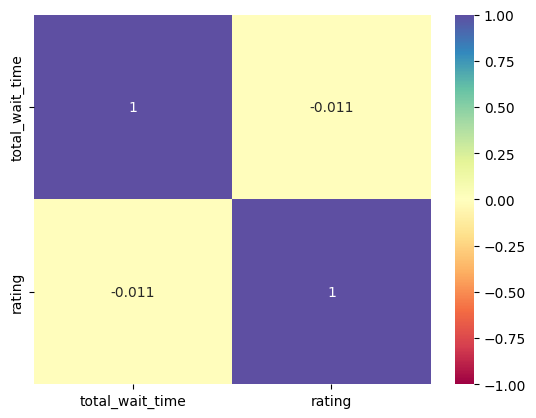

In [ ]:
sns.heatmap(df[['total_wait_time','rating']].corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)

*   There is a slightly stronger negative correlation between the total_wait_time for the customer and the rating, indicating the longer the wait time, the lower the rating.

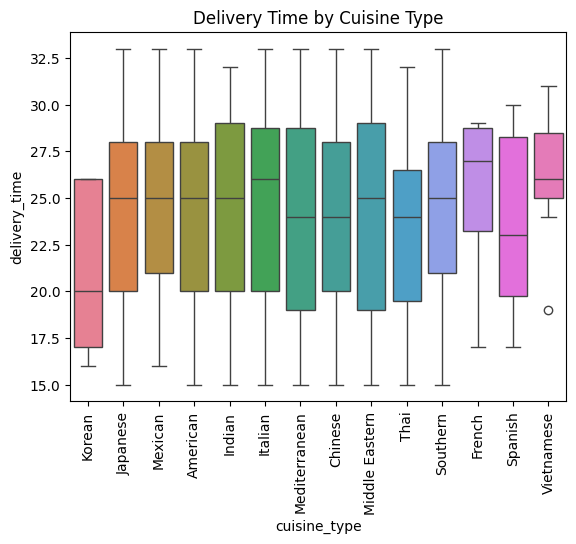

In [ ]:
# looking at delivery time and cuisine type
sns.boxplot(data=df, x='cuisine_type', y='delivery_time', hue='cuisine_type')
plt.title('Delivery Time by Cuisine Type')
plt.xticks(rotation=90)
plt.show()

*   Korean delivery time is much lower than any other cuisine type.

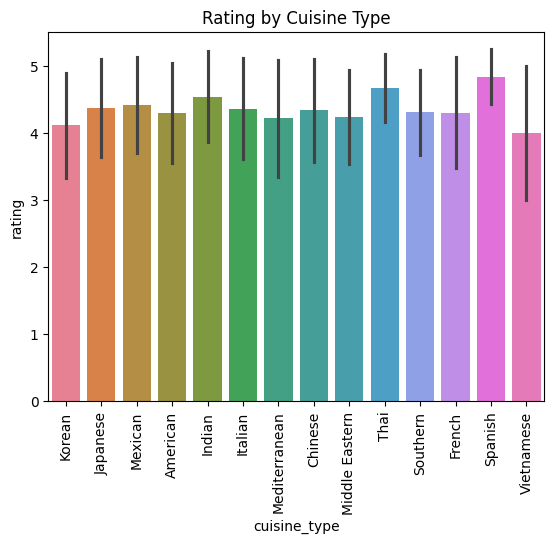

In [ ]:
# looking at cuisine type and rating
sns.barplot(data=df, x='cuisine_type', y='rating', errorbar='sd',hue='cuisine_type')
plt.title('Rating by Cuisine Type')
plt.xticks(rotation=90)
plt.show()

*   This chart shows that Spanish cuisine has the highest average rating and the least spread among ratings.
*   Vietnamese cuisine shows the lowest average rating with a high amount of variability.

In [ ]:
# count the number of orders by cuisine type
order_counts_by_cuisine = df.groupby('cuisine_type')['order_id'].count()
sorted_order_counts = order_counts_by_cuisine.sort_values(ascending=False)
sorted_order_counts

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: order_id, dtype: int64

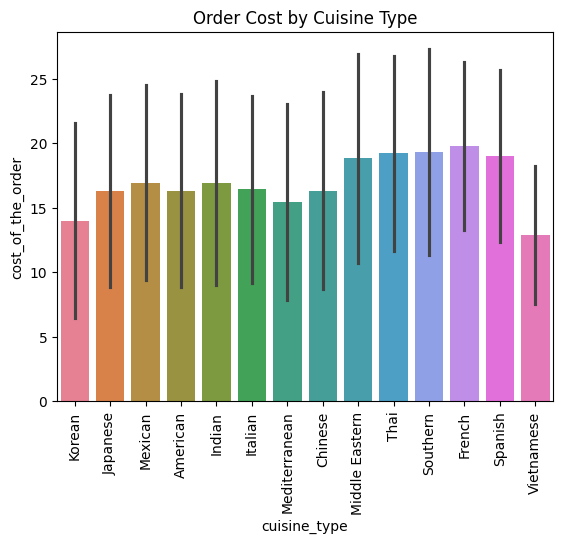

In [ ]:
# cost and cuisine
sns.barplot(data=df, x='cuisine_type', y='cost_of_the_order', errorbar='sd',hue='cuisine_type')
plt.title('Order Cost by Cuisine Type')
plt.xticks(rotation=90)
plt.show()


TO DO: numerical and categorical relationships!!!
restaurant and rating
cuisine and rating
restaurant and food prep time
cost and restaurant
day of the week and rating
day of the week and food prep time
day of the week and food delivery time

<ipython-input-46-4e6d61141544>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(data=df_top_10_restaurants,x='restaurant_name',y='rating',ci='sd',hue='restaurant_name')


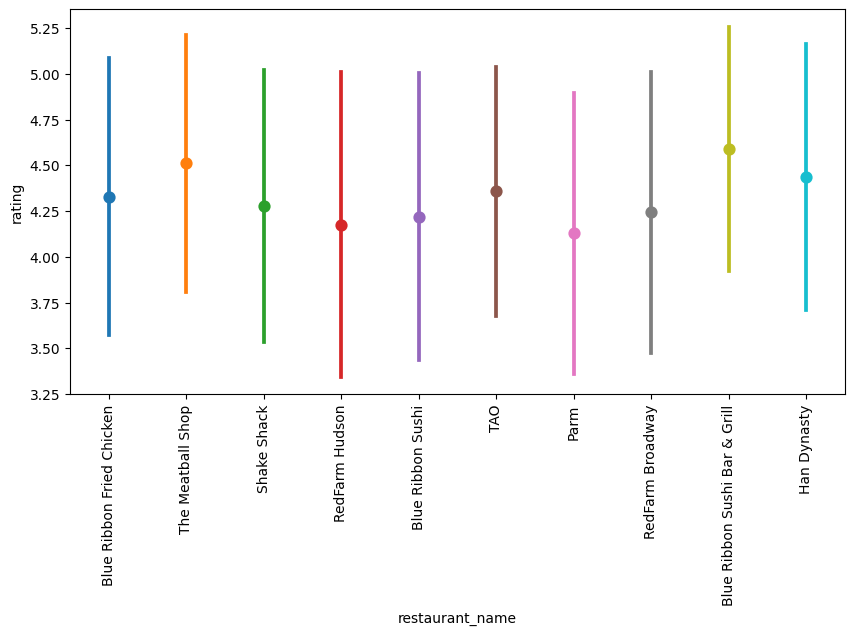

In [ ]:
# restaurant and rating
plt.figure(figsize=(10,5))
sns.pointplot(data=df_top_10_restaurants,x='restaurant_name',y='rating',ci='sd',hue='restaurant_name')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df_top_10_restaurants.groupby('restaurant_name')['rating'].mean()

restaurant_name
Blue Ribbon Fried Chicken        4.328125
Blue Ribbon Sushi                4.219178
Blue Ribbon Sushi Bar & Grill    4.590909
Han Dynasty                      4.434783
Parm                             4.128205
RedFarm Broadway                 4.243902
RedFarm Hudson                   4.176471
Shake Shack                      4.278195
TAO                              4.357143
The Meatball Shop                4.511905
Name: rating, dtype: float64

In [ ]:
df['rating'].mean()

4.344234079173838

In [ ]:
df_top_10_restaurants['rating'].mean()

4.316081330868761

*   The top 10 restaurants have an average rating of

In [ ]:
# highest rated restaurants
average_ratings = df.groupby('restaurant_name')['rating'].mean()
top_rated_restaurants = average_ratings.sort_values(ascending=False).head(20)
print(top_rated_restaurants)

restaurant_name
'wichcraft                       5.0
Ravagh Persian Grill             5.0
Chola Eclectic Indian Cuisine    5.0
Chote Nawab                      5.0
Junoon                           5.0
Socarrat Paella Bar              5.0
DespaÌ±a                         5.0
Dig Inn Seasonal Market          5.0
Saravanaa Bhavan                 5.0
Donburi-ya                       5.0
Dos Caminos                      5.0
Dos Caminos Soho                 5.0
Samurai Mama                     5.0
El Parador Cafe                  5.0
Prosperity Dumpling              5.0
Carmine's                        5.0
Galli Restaurant                 5.0
Grand Sichuan International      5.0
Philippe Chow                    5.0
Olive Garden                     5.0
Name: rating, dtype: float64


In [ ]:
# where does most of the revenue come from?


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# create dataframe with restaurants ratings that are not null
df_with_ratings = df.dropna(subset=['rating'])
df_with_ratings.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_wait_time
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3.0,20,24,44
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3.0,33,30,63


In [ ]:
df_with_ratings.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
total_wait_time          0
dtype: int64

In [ ]:
# add a column with the average rating corresponding to each restaurant
df_with_ratings['restaurant_average_rating'] = df.groupby('restaurant_name')['rating'].transform('mean')
df_with_ratings.head()

<ipython-input-54-e0cc010f700d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_ratings['restaurant_average_rating'] = df.groupby('restaurant_name')['rating'].transform('mean')


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_wait_time,restaurant_average_rating
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51,4.272727
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40,4.328125
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49,4.000000
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3.0,20,24,44,4.400000
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3.0,33,30,63,4.500000


In [ ]:
# filter the df to just those with ratings at 4 and above
df_above_4 = df_with_ratings.loc[df_with_ratings['restaurant_average_rating']>=4]


In [ ]:
# get restaurant names with a rating count of more than 50
rated_order_counts = df_above_4['restaurant_name'].value_counts()
print(rated_order_counts[rated_order_counts > 50])


restaurant_name
Shake Shack                  133
The Meatball Shop             84
Blue Ribbon Sushi             73
Blue Ribbon Fried Chicken     64
Name: count, dtype: int64


#### Observations:
*   There are four restaurants that meet the criteria: Shake Shack, The Meatbal Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken.




### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# orders greater than $20
df_greater_than_20 = df.loc[df['cost_of_the_order'] > 20]
# 25% of sum
first_charge = df_greater_than_20['cost_of_the_order'].sum()*0.25

In [ ]:
# orders that cost more than $5 and less than or equal to $20
df_between_5_and_20 = df.loc[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]
# 15% of sum
second_charge = df_between_5_and_20['cost_of_the_order'].sum()*0.15


In [ ]:
net_revenue = first_charge + second_charge
print(net_revenue)

6166.303


In [ ]:
# which restaurants, cuisine type, and days bring in the most revenue?

# function to calculate the revenue by the company's conditions
def calculate_revenue(cost):
  if cost > 20:
    return cost * 0.25
  elif cost > 5:
    return cost * 0.15
  else:
    return 0

# apply to a new column called 'revenue'
df['revenue'] = df['cost_of_the_order'].apply(calculate_revenue)
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_wait_time,revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,45,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,48,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49,1.7385


In [ ]:
# revenue by restaurant

restaurant_revenue = df.groupby('restaurant_name')['revenue'].sum().reset_index()

top_restaurant_revenue = restaurant_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)

print(top_restaurant_revenue.head(20))

                          restaurant_name   revenue
0                             Shake Shack  703.6070
1                       The Meatball Shop  419.8285
2                       Blue Ribbon Sushi  360.4605
3               Blue Ribbon Fried Chicken  340.2035
4                                    Parm  218.5570
5                        RedFarm Broadway  191.4675
6                          RedFarm Hudson  180.9340
7                                     TAO  167.3570
8                             Han Dynasty  149.3985
9                                Rubirosa  140.8085
10                       Sushi of Gari 46  130.4985
11                         Nobu Next Door  115.8250
12          Blue Ribbon Sushi Bar & Grill  114.9485
13  Chipotle Mexican Grill $1.99 Delivery  106.6605
14            Five Guys Burgers and Fries  100.5465
15                                 Momoya   95.7725
16              Blue Ribbon Sushi Izakaya   93.0955
17                      Jack's Wife Freda   84.0855
18          

In [ ]:
average_restaurant_revenue = df.groupby('restaurant_name')['revenue'].mean()
highest_average_revenue_restaurant = average_restaurant_revenue.sort_values(ascending=False)
highest_average_revenue_restaurant.head(20)

restaurant_name
Kambi Ramen House             8.232500
Emporio                       7.857500
Bhatti Indian Grill           7.778750
Haru Gramercy Park            7.457500
Il Bambino                    7.312500
Lucky Strike                  7.312500
Sarabeth's                    7.283333
Rohm Thai                     7.275000
67 Burger                     7.262500
Klong                         7.262500
Song Thai Restaurant & Bar    6.675000
Socarrat Paella Bar           6.305000
Byblos Restaurant             6.183750
Posto                         6.062500
Philippe Chow                 6.050000
Bistango                      5.760000
Junoon                        5.578100
Kanoyama                      5.494667
Carmine's                     5.247333
Delicatessen                  5.220100
Name: revenue, dtype: float64

In [ ]:
# revenue by cuisine
cuisine_revenue = df.groupby('cuisine_type')['revenue'].sum().reset_index()
cuisine_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)

,cuisine_type,revenue
0,American,1878.2740
1,Japanese,1478.2445
2,Italian,966.8845
3,Chinese,690.0405
4,Mexican,256.6930
5,Indian,246.9940
6,Middle Eastern,193.5535
7,Mediterranean,136.3280
8,Thai,78.0525
9,French,76.1925


In [ ]:
# average revenue for an order of a specific cuisine type
average_cuisine_revenue = df.groupby('cuisine_type')['revenue'].mean()
print(average_cuisine_revenue.sort_values(ascending = False))


cuisine_type
French            4.232917
Thai              4.108026
Southern          4.044324
Middle Eastern    3.950071
Spanish           3.936375
Indian            3.383479
Mexican           3.333675
Italian           3.244579
American          3.216223
Chinese           3.209491
Japanese          3.145201
Mediterranean     2.963652
Korean            2.561769
Vietnamese        2.250429
Name: revenue, dtype: float64


In [ ]:
# revenue by day_of_the_week

day_of_the_week_revenue = df.groupby('day_of_the_week')['revenue'].sum()
print(day_of_the_week_revenue)

day_of_the_week
Weekday    1754.3345
Weekend    4411.9685
Name: revenue, dtype: float64


#### Observations:
*   The net revenue is $6,166.30 across all orders.
*   Shake Shack brings in significantly more revenue, due to the order volume.
*   Shake Shack accounts for 11.4% of all revenue.
*   American cuisine type brings in the most revenue.
*   Weekends bring in significantly more revenue.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
df_more_than_60 = df.loc[df['total_wait_time'] > 60]
number_above_60 = df_more_than_60.shape[0]
print('Above 60 minutes: ', number_above_60)
total_orders = df.shape[0]
print(' Total orders: ', total_orders)
percentage = number_above_60 / total_orders
print('Percentage: ', percentage)

Above 60 minutes:  200
 Total orders:  1898
Percentage:  0.1053740779768177


#### Observations:
*   Just above 10 percent of the orders take more than 60 minutes from the time the order is placed to its delivery.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# group by day_of_the_week

mean_delivery_time = df.groupby('day_of_the_week')['delivery_time'].mean()
print(mean_delivery_time)

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


#### Observations:
*   The mean delivery time for Weekdays is about 28 minutes.
*   The mean delivery time for Weekends is about 22 minutes.
*   Delivery time on weekdays on average takes about 6 minutes longer.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
1.   The ratings are limited to only 3, 4, and 5, and so the ratings do not reveal a wide range of sentiment from the customers. Most of the ratings are 4 or above.
2.   American cuisine is the most popular and lucrative due to order volume.
3.   The main ways that cuisine and restaurants are distinguished are by the order volume and day of the week. There is not a significant difference in ratings, revenue per order, or total time per order.



### Recommendations:

*  The business should should continue to maximize its relationship with the highest revenue producing restaurants and cuisines.
*   The business should continue rewarding return customers and frequently ordered restaurants and ensure that they can meet the demand on the weekends.
*   If they want to increase traffic during weekdays, they could offer incentives.
*   To make the rating information more useful, they should implement ratings 1-5 and an option for written feedback.

In [ ]:
!jupyter nbconvert --to html /content/drive/MyDrive/AIML_Program/Python_Foundations/Learner_Notebook_Full_Code.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/AIML_Program/Python_Foundations/Learner_Notebook_Full_Code.ipynb to html
[NbConvertApp] Writing 1325834 bytes to /content/drive/MyDrive/AIML_Program/Python_Foundations/Learner_Notebook_Full_Code.html


---